In [6]:
import pandas as pd

pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_columns', 20)

df = pd.read_csv('/workspaces/IESO/datasets/processed/merged_2025.csv', parse_dates=['Date'])
print(f"Rows: {len(df):,}  |  Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()

Rows: 8,759  |  Date range: 2025-01-01 → 2025-12-31


,Date,Hour,Month,Month_Name,Week,DayOfWeek,Total_Imp,Total_Exp,Total_Flow,Net_Export,Ontario_Demand,Market_Demand
0,2025-01-01,1,1,Jan,1,Wednesday,94,3502,3843,3408,13887,17247
1,2025-01-01,2,1,Jan,1,Wednesday,94,3774,4127,3680,13722,17355
2,2025-01-01,3,1,Jan,1,Wednesday,94,4129,4476,4035,13688,17638
3,2025-01-01,4,1,Jan,1,Wednesday,94,3587,4097,3493,13613,17065
4,2025-01-01,5,1,Jan,1,Wednesday,94,4071,4463,3977,13593,17498


FileNotFoundError: [Errno 2] No such file or directory: 'charts/chart1_monthly_net_export.png'

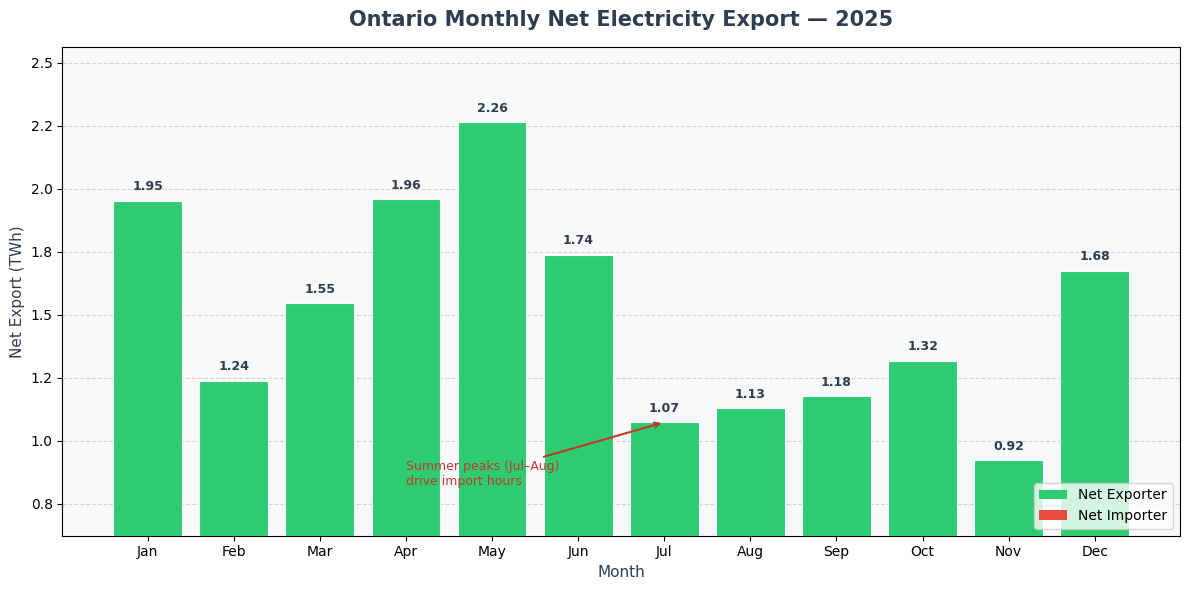

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# ── Monthly net export ──────────────────────────────────────────────────────
monthly = df.groupby(['Month', 'Month_Name'])['Net_Export'].sum().reset_index().sort_values('Month')
monthly['Net_Export_TWh'] = monthly['Net_Export'] / 1_000_000

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month_Name'] = pd.Categorical(monthly['Month_Name'], categories=month_order, ordered=True)
monthly = monthly.sort_values('Month_Name')

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly['Net_Export_TWh']]

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(monthly['Month_Name'], monthly['Net_Export_TWh'], color=colors,
              edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, monthly['Net_Export_TWh']):
    offset = 0.03 if val >= 0 else -0.06
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2c3e50')

ax.axhline(0, color='#2c3e50', linewidth=1.2, zorder=4)
ax.set_title('Ontario Monthly Net Electricity Export — 2025',
             fontsize=15, fontweight='bold', pad=15, color='#2c3e50')
ax.set_xlabel('Month', fontsize=11, color='#2c3e50')
ax.set_ylabel('Net Export (TWh)', fontsize=11, color='#2c3e50')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.set_ylim(monthly['Net_Export_TWh'].min() - 0.3, monthly['Net_Export_TWh'].max() + 0.3)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

legend_elements = [Patch(facecolor='#2ecc71', label='Net Exporter'),
                   Patch(facecolor='#e74c3c', label='Net Importer')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.annotate('Summer peaks (Jul–Aug)\ndrive import hours',
            xy=('Jul', monthly[monthly['Month_Name'] == 'Jul']['Net_Export_TWh'].values[0]),
            xytext=('Apr', monthly['Net_Export_TWh'].min() - 0.1),
            fontsize=9, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

plt.tight_layout()
plt.savefig('charts/chart1_monthly_net_export.png', dpi=150, bbox_inches='tight')
plt.show()